## **Вариант 8** ##

### Рухтина Полина, Маннанова Лилиана, Маликова Камалия 

В данной работе проводится анализ данных стран мира по индексу искусственного интеллекта (AI Index). Цель исследования — выявить скрытые закономерности в данных и сгруппировать страны на основе их показателей развития ИИ без использования заранее известных меток (обучение без учителя).

После построения моделей кластеризации будет проведён анализ полученных групп, чтобы понять, какие признаки наиболее сильно влияют на распределение стран по кластерам.

## Аналитика данных и подготовка ##


Задачи: 

   • Разведочный анализ данных (EDA): статистики, распределения, выбросы
   
   • Описание датасета: источники, размерность, типы признаков, целевая переменная
   
   • Анализ важности признаков (correlation matrix, mutual information, feature importance)


### Импорт бибилиотек

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings

In [35]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Просмотр набора данных

In [36]:
df = pd.read_csv('AI_index_db.csv')
display(df.head())
print(f" Датасет загружен: {df.shape[0]} стран, {df.shape[1]} признаков")

,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy


 Датасет загружен: 62 стран, 13 признаков


### ОПИСАНИЕ ПРИЗНАКОВ ###

Country - Название страны

Talent - Уровень талантов и кадров в сфере ИИ 

Infrastructure - Технологическая инфраструктура 

Operating Environment - Условия для ведения бизнеса

Research - Научные исследования в области ИИ 

Development - Практическая разработка ИИ-решений 

Government Strategy - Государственная стратегия по ИИ 

Commercial - Коммерциализация ИИ-технологий 

Total score - Итоговый рейтинг страны 

Region - Географический регион

Cluster - Группа развития ИИ (Power players, Traditional champions, и т.д.)

Income group - Уровень дохода страны

Political regime - Политический режим

 62 стран, 13 признаков

In [37]:
display(df[['Total score', 'Talent', 'Infrastructure', 'Research', 'Development']].describe().round(2))

,Total score,Talent,Infrastructure,Research,Development
count,62.00,62.00,62.00,62.00,62.00
mean,23.91,16.80,63.50,16.61,14.82
std,15.12,15.21,20.22,17.41,19.42
min,0.00,0.00,0.00,0.00,0.00
25%,14.80,7.36,55.86,3.03,1.20
50%,23.22,13.44,65.23,12.93,9.00
75%,30.49,24.57,75.95,25.41,19.98
max,100.00,100.00,100.00,100.00,100.00


## КОРРЕЛЯЦИИ МЕЖДУ ПРИЗНАКАМИ" ##

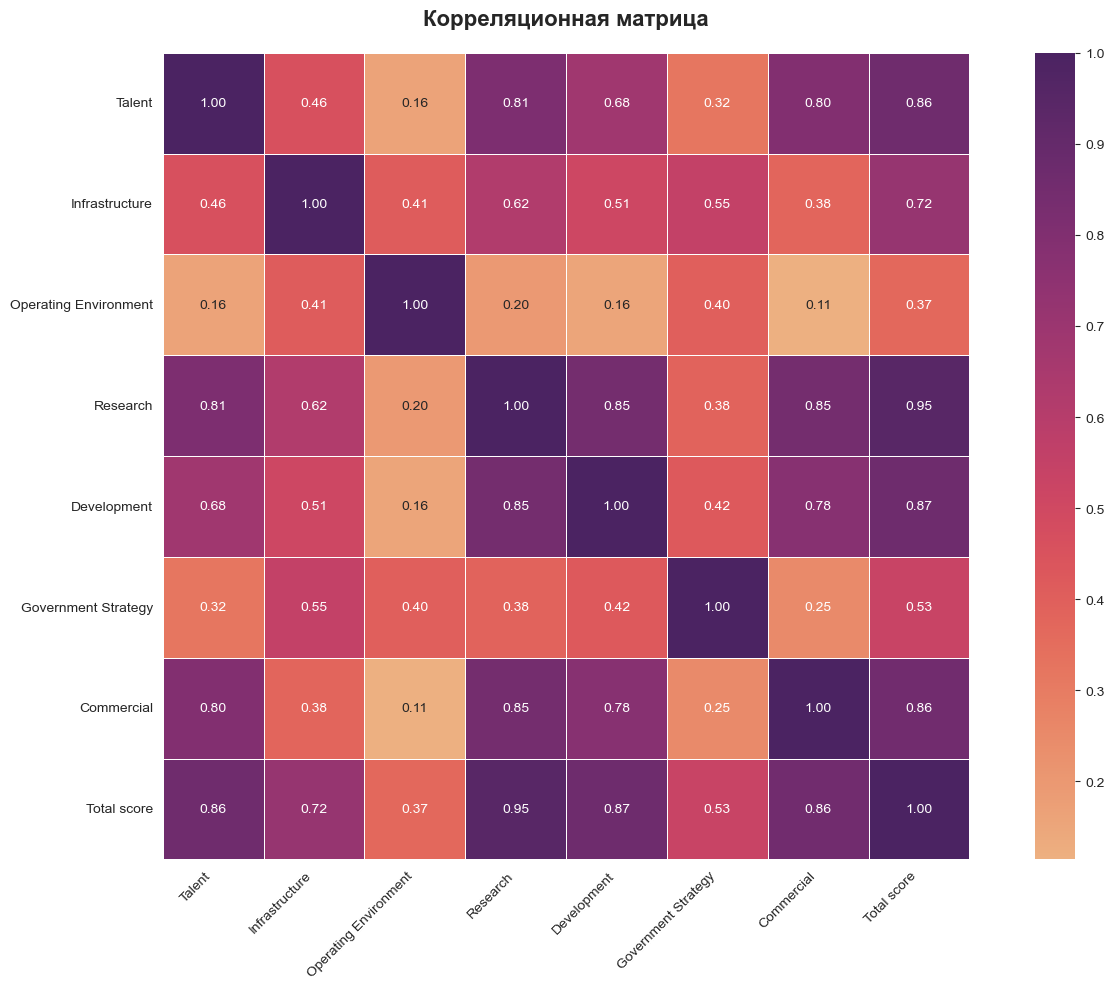

In [38]:
num_cols = ['Talent', 'Infrastructure', 'Operating Environment', 'Research', 
            'Development', 'Government Strategy', 'Commercial', 'Total score']

plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), 
            cmap=sns.color_palette("flare", as_cmap=True), 
            annot=True, 
            fmt='.2f',
            vmax=1.0,
            square=True,
            linewidths=0.5)
plt.title('Корреляционная матрица', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [39]:
corr_with_total = df[num_cols].corr()['Total score'].sort_values(ascending=False)
display(corr_with_total[1:].round(3))

Research                 0.946
Development              0.866
Talent                   0.862
Commercial               0.858
Infrastructure           0.716
Government Strategy      0.532
Operating Environment    0.369
Name: Total score, dtype: float64

## РАСПРЕДЕЛЕНИЕ ДАННЫХ ##

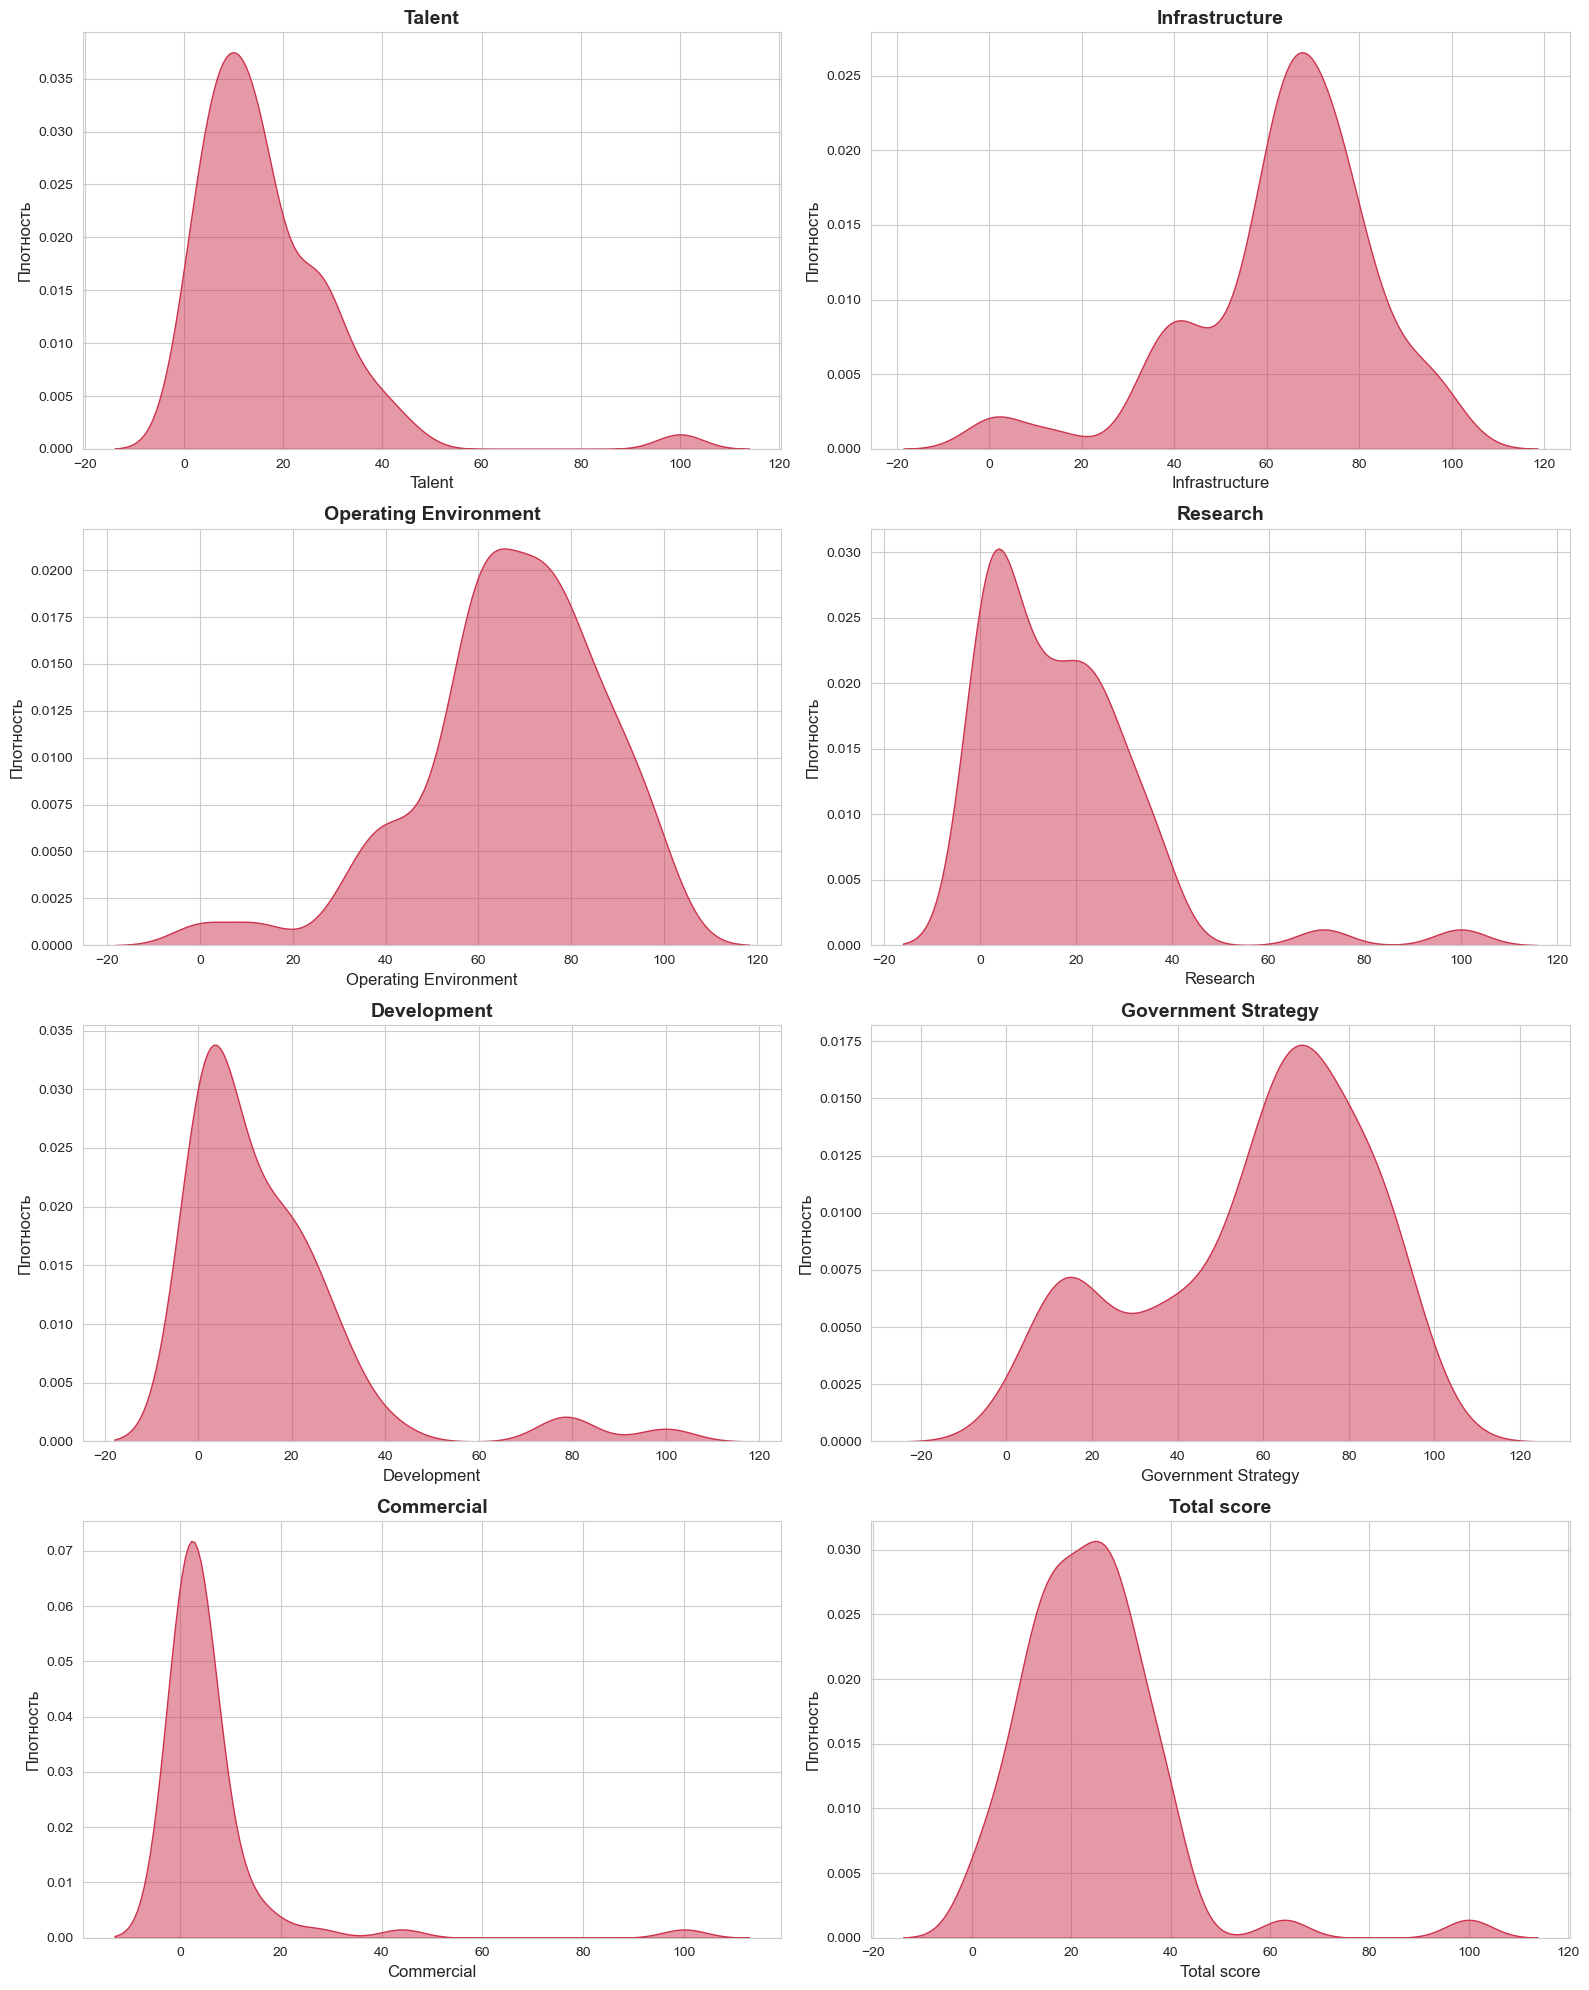


 Выводы:
   • Некоторые признаки близки к нормальному распределению
   • Остальные имеют скос или несколько мод
   • Признаки имеют разные масштабы измерений → нужна нормализация



In [40]:

features = ['Talent', 'Infrastructure', 'Operating Environment', 'Research', 
            'Development', 'Government Strategy', 'Commercial']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
plt.subplots_adjust(hspace=0.5)

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, fill=True, alpha=0.5, bw_adjust=0.7, 
                color=[0.8, 0.2, 0.3], ax=axes[i])
    axes[i].set_title(col, fontweight='bold', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Плотность', fontsize=12)

sns.kdeplot(data=df, x='Total score', fill=True, alpha=0.5, bw_adjust=0.7, 
            color=[0.8, 0.2, 0.3], ax=axes[7])
axes[7].set_title('Total score', fontweight='bold', fontsize=14)
axes[7].set_xlabel('Total score', fontsize=12)
axes[7].set_ylabel('Плотность', fontsize=12)

plt.tight_layout()
plt.show()

print("""
 Выводы:
   • Некоторые признаки близки к нормальному распределению
   • Остальные имеют скос или несколько мод
   • Признаки имеют разные масштабы измерений → нужна нормализация
""")

## Выбросы данных

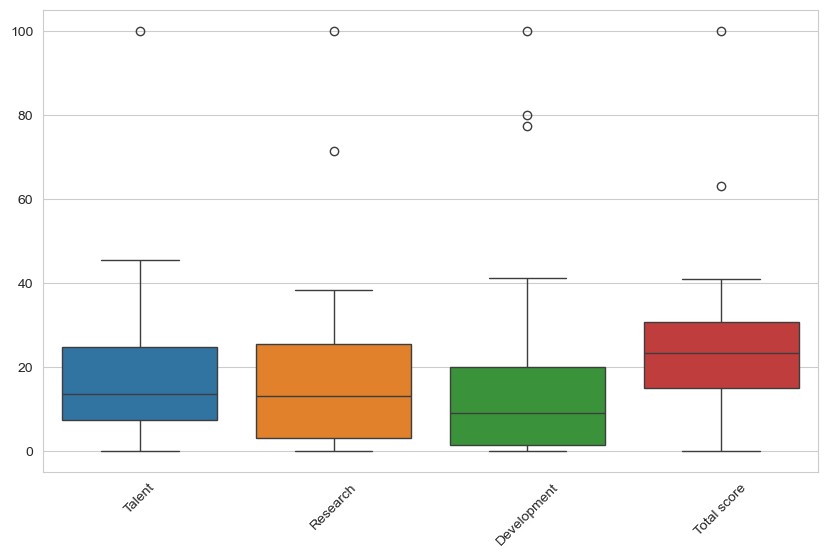

In [106]:
cols = ['Talent', 'Research', 'Development', 'Total score']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[cols])
plt.xticks(rotation=45)
plt.show()

In [42]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\n{col}:")
    print(f"  Границы: от {lower:.1f} до {upper:.1f}")
    print(f"  Найдено выбросов: {len(outliers)}")
    
    if len(outliers) > 0:
        print(f"  Страны: {', '.join(outliers['Country'].tolist())}")


Talent:
  Границы: от -18.4 до 50.4
  Найдено выбросов: 1
  Страны: United States of America

Research:
  Границы: от -30.5 до 59.0
  Найдено выбросов: 2
  Страны: United States of America, China

Development:
  Границы: от -27.0 до 48.1
  Найдено выбросов: 3
  Страны: United States of America, China, South Korea

Total score:
  Границы: от -8.7 до 54.0
  Найдено выбросов: 2
  Страны: United States of America, China


Размер: (62, 9)
Всего найдено выбросов: 20


,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Total outliers
Country,,,,,,,,,
United States of America,1,0,0,1,1,0,1,1,5
China,0,0,0,1,1,0,1,1,4
United Kingdom,0,0,0,0,0,0,1,0,1
Canada,0,0,0,0,0,0,1,0,1
Israel,0,0,0,0,0,0,1,0,1
Singapore,0,0,0,0,0,0,1,0,1
South Korea,0,0,0,0,1,0,0,0,1
Estonia,0,0,0,0,0,0,1,0,1
Egypt,0,0,1,0,0,0,0,0,1


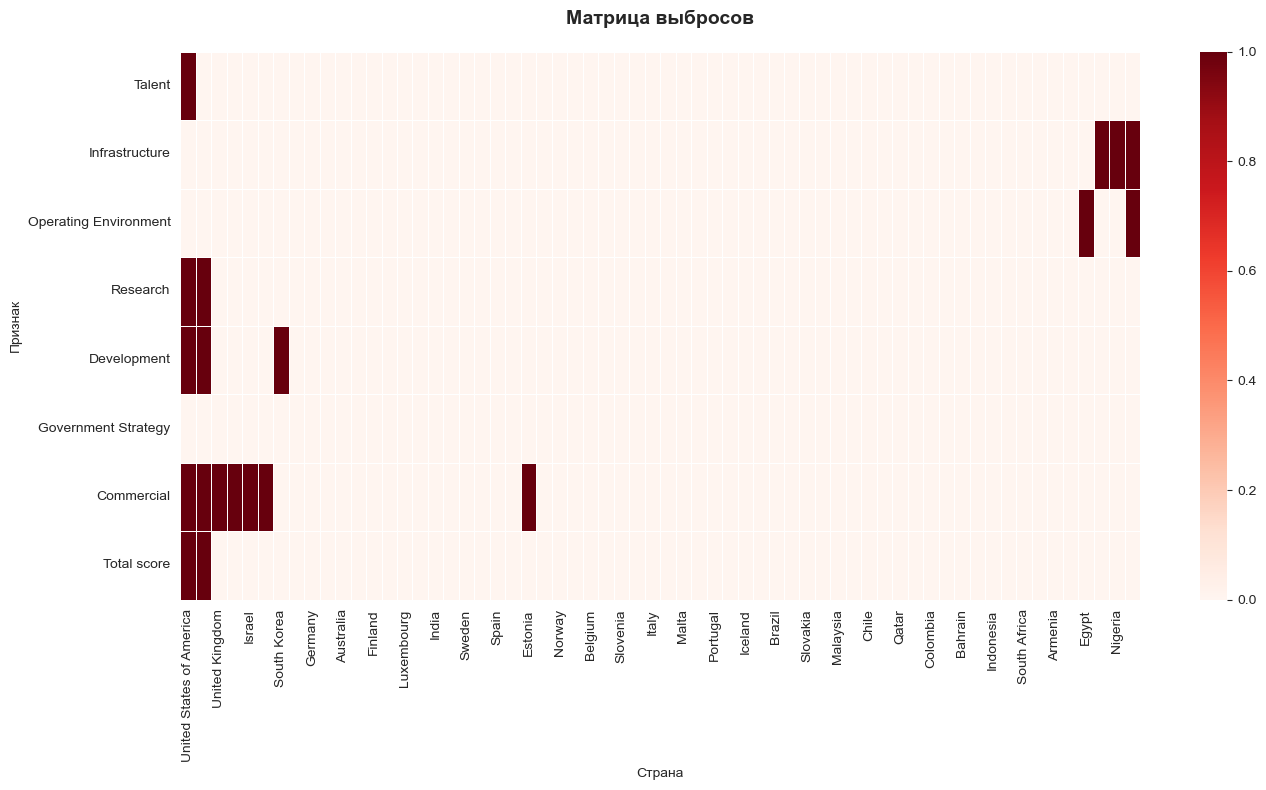

In [43]:
numeric_cols = ['Talent', 'Infrastructure', 'Operating Environment', 
                'Research', 'Development', 'Government Strategy', 
                'Commercial', 'Total score']

# Создаем DataFrame
outlier_summary = pd.DataFrame(index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outlier_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    outlier_summary[col] = outlier_mask.astype(int)

# Добавляем названия стран и устанавливаем как индекс
outlier_summary['Country'] = df['Country'].values
outlier_summary = outlier_summary.set_index('Country') 
outlier_summary['Total outliers'] = outlier_summary[numeric_cols].sum(axis=1)

# Проверяем
print(f"Размер: {outlier_summary.shape}")
print(f"Всего найдено выбросов: {outlier_summary['Total outliers'].sum()}")
display(outlier_summary[outlier_summary['Total outliers'] > 0].head(10))

# Рисуем heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(outlier_summary[numeric_cols].T, 
            cmap='Reds', 
            linewidths=0.5)
plt.title('Матрица выбросов', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Страна')
plt.ylabel('Признак')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## НОРМАЛИЗАЦИЯ ##

In [44]:
scaler = MinMaxScaler()
X = df[features].copy()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)
display(X_scaled.describe().round(3))
print(" MinMaxScaler применён (диапазон [0, 1])")

,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial
count,62.000,62.000,62.000,62.000,62.000,62.000,62.000
mean,0.168,0.635,0.669,0.166,0.148,0.579,0.062
std,0.152,0.202,0.200,0.174,0.194,0.263,0.140
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.074,0.559,0.581,0.030,0.012,0.410,0.007
50%,0.134,0.652,0.695,0.129,0.090,0.639,0.026
75%,0.246,0.759,0.805,0.254,0.200,0.780,0.053
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


 MinMaxScaler применён (диапазон [0, 1])


## Моделирование ##

### Кластеризация стран

 Цели анализа:
 
   • Изучить закономерности в данных AI Index
   
   • Применить метод главных компонент (PCA)
   
   • Выполнить кластеризацию 3 методами
   
   • Сравнить результаты и проанализировать кластеры

In [57]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [58]:
features_for_clustering = ['Talent', 'Infrastructure', 'Operating Environment', 
                          'Research', 'Development', 'Government Strategy', 'Commercial']

X = df[features_for_clustering].copy()
print("\nРазмер матрицы признаков:", X.shape)
X.head()


Размер матрицы признаков: (62, 7)


,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial
0,100.00,94.02,64.56,100.00,100.00,77.39,100.00
1,16.51,100.00,91.57,71.42,79.97,94.87,44.02
2,39.65,71.43,74.65,36.50,25.03,82.82,18.91
3,31.28,77.05,93.94,30.67,25.78,100.00,14.88
4,35.76,67.58,82.44,32.63,27.96,43.91,27.33


In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)

print("Данные после масштабирования:")
X_scaled_df.head()

Данные после масштабирования:


,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial
0,5.512738,1.521720,-0.119237,4.827769,4.421927,0.749787,6.742445
1,-0.019419,1.819917,1.242259,3.173162,3.382058,1.421065,2.719746
2,1.513868,0.395251,0.389370,1.151509,0.529815,0.958313,0.915352
3,0.959261,0.675497,1.361723,0.813988,0.568752,1.618071,0.625758
4,1.256111,0.203268,0.782042,0.927460,0.681928,-0.535934,1.520410


In [ ]:
МЕТОД ЛОКТЯ (Elbow Method)

In [64]:
inertia = [] 
K_range = range(2, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_) 

In [ ]:
МЕТОД СИЛУЭТА (Silhouette Method)

In [65]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

In [ ]:
Визуализируем оба метода

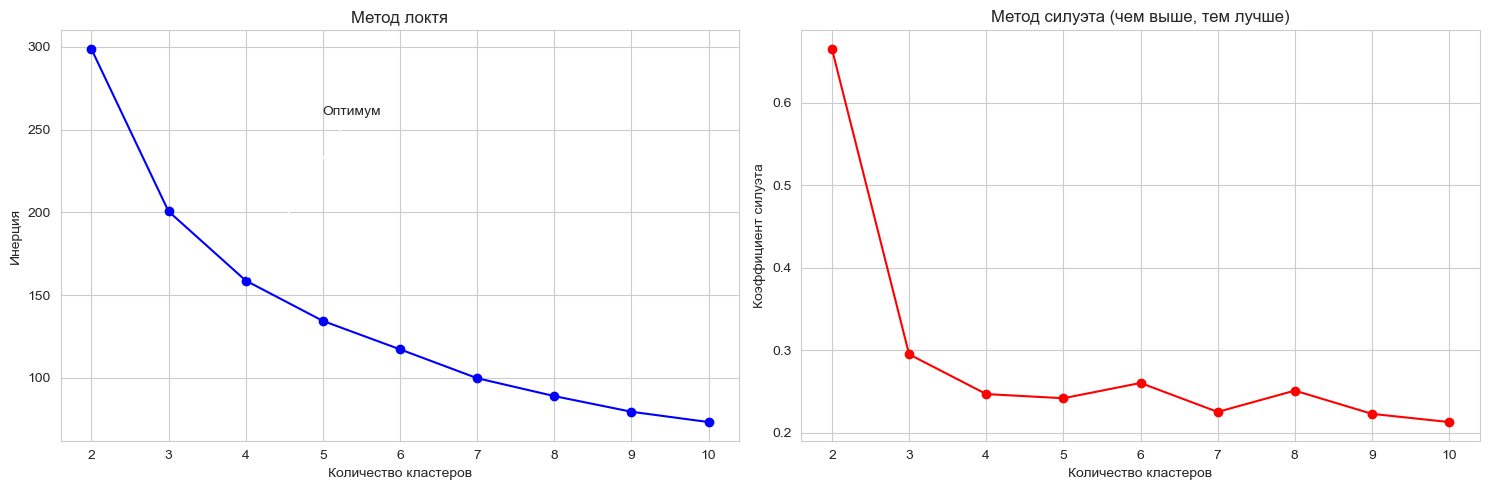

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График локтя
ax1.plot(K_range, inertia, 'bo-')
ax1.set_xlabel('Количество кластеров')
ax1.set_ylabel('Инерция')
ax1.set_title('Метод локтя')
ax1.grid(True)
ax1.annotate('Оптимум', xy=(4, inertia[2]), xytext=(5, inertia[2]+100),
            arrowprops=dict(arrowstyle='->'))

# График силуэта
ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Количество кластеров')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Метод силуэта (чем выше, тем лучше)')
ax2.grid(True)

plt.tight_layout()
plt.show()


In [107]:
best_k = K_range[np.argmax(silhouette_scores)]
print(f"Оптимальное количество кластеров: {best_k}")
print(f"Коэффициент силуэта: {max(silhouette_scores):.3f}")

Оптимальное количество кластеров: 2
Коэффициент силуэта: 0.665


### Метод - K-MEANS

In [70]:
n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_kmeans = df.copy()
df_kmeans['Cluster_KMeans'] = kmeans_labels

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"Коэффициент силуэта = {kmeans_silhouette:.3f}")

print("\nРаспределение по кластерам K-Means:")
print(df_kmeans['Cluster_KMeans'].value_counts().sort_index())

print("\nПримеры стран в каждом кластере K-Means:")
for cluster in range(n_clusters):
    countries = df_kmeans[df_kmeans['Cluster_KMeans'] == cluster]['Country'].head(3).tolist()
    print(f"Кластер {cluster}: {', '.join(countries)}")

Коэффициент силуэта = 0.247

Распределение по кластерам K-Means:
Cluster_KMeans
0    27
1    21
2    13
3     1
Name: count, dtype: int64

Примеры стран в каждом кластере K-Means:
Кластер 0: Spain, Austria, Estonia
Кластер 1: China, United Kingdom, Canada
Кластер 2: Iceland, Bahrain, Vietnam
Кластер 3: United States of America


### Метод - Agglomerative (Иерархическая)

In [71]:
agglo = AgglomerativeClustering(n_clusters=n_clusters)
agglo_labels = agglo.fit_predict(X_scaled)

df_agglo = df.copy()
df_agglo['Cluster_Agglo'] = agglo_labels

agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
print(f"Коэффициент силуэта = {agglo_silhouette:.3f}")

print("\nРаспределение по кластерам Agglomerative:")
print(df_agglo['Cluster_Agglo'].value_counts().sort_index())

print("\nПримеры стран в каждом кластере Agglomerative:")
for cluster in range(n_clusters):
    countries = df_agglo[df_agglo['Cluster_Agglo'] == cluster]['Country'].head(3).tolist()
    print(f"Кластер {cluster}: {', '.join(countries)}")

Коэффициент силуэта = 0.167

Распределение по кластерам Agglomerative:
Cluster_Agglo
0    26
1    16
2    19
3     1
Name: count, dtype: int64

Примеры стран в каждом кластере Agglomerative:
Кластер 0: China, United Kingdom, Canada
Кластер 1: Austria, Estonia, Saudi Arabia
Кластер 2: Greece, Hungary, Chile
Кластер 3: United States of America


### Метод - DBSCAN (Плотностная)

In [108]:
eps_values = [0.5, 0.7, 0.9, 1.1]
min_samples_values = [3, 4, 5]

best_score = -1
best_eps = None
best_min_samples = None
best_labels = None

print("Параметры:")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шум={n_noise}")
        
        if n_clusters > 1 and n_noise < 10:
            try:
                mask = labels != -1
                score = silhouette_score(X_scaled[mask], labels[mask])
                if score > best_score:
                    best_score = score
                    best_eps = eps
                    best_min_samples = min_samples
                    best_labels = labels
            except:
                pass

if best_labels is not None:
    dbscan_labels = best_labels
    print(f"\nЛУЧШИЕ ПАРАМЕТРЫ:")
    print(f"eps={best_eps}, min_samples={best_min_samples}")
    print(f"Силуэт (без шума): {best_score:.3f}")
else:
    dbscan = DBSCAN(eps=0.8, min_samples=3)
    dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nРЕЗУЛЬТАТЫ DBSCAN:")
print(f"Количество кластеров: {n_clusters_db}")
print(f"Количество выбросов (шум): {n_noise}")
print(f"Процент выбросов: {n_noise/len(dbscan_labels)*100:.1f}%")

df_dbscan = df.copy()
df_dbscan['Cluster'] = dbscan_labels

print("\n Состав кластеров:")
for cluster in sorted(set(dbscan_labels)):
    if cluster == -1:
        countries = df_dbscan[df_dbscan['Cluster'] == cluster]['Country'].tolist()
        print(f"\n ВЫБРОСЫ ({len(countries)} стран):")
        print(', '.join(countries[:10])) 
    else:
        countries = df_dbscan[df_dbscan['Cluster'] == cluster]['Country'].tolist()
        print(f"\n Кластер {cluster} ({len(countries)} стран):")
        print(', '.join(countries[:5]))

Параметры:
eps=0.5, min_samples=3: кластеров=2, шум=55
eps=0.5, min_samples=4: кластеров=1, шум=58
eps=0.5, min_samples=5: кластеров=0, шум=62
eps=0.7, min_samples=3: кластеров=2, шум=54
eps=0.7, min_samples=4: кластеров=1, шум=57
eps=0.7, min_samples=5: кластеров=1, шум=57
eps=0.9, min_samples=3: кластеров=3, шум=35
eps=0.9, min_samples=4: кластеров=3, шум=41
eps=0.9, min_samples=5: кластеров=3, шум=43
eps=1.1, min_samples=3: кластеров=1, шум=28
eps=1.1, min_samples=4: кластеров=1, шум=28
eps=1.1, min_samples=5: кластеров=1, шум=31

РЕЗУЛЬТАТЫ DBSCAN:
Количество кластеров: 3
Количество выбросов (шум): 42
Процент выбросов: 67.7%

 Состав кластеров:

 ВЫБРОСЫ (42 стран):
United States of America, China, United Kingdom, Canada, Israel, Singapore, South Korea, The Netherlands, Germany, Australia

 Кластер 0 (4 стран):
France, Finland, Denmark, Spain

 Кластер 1 (3 стран):
Austria, Belgium, Italy

 Кластер 2 (13 стран):
Malta, Portugal, Czech Republic, Lithuania, Brazil


### Сравнение методов кластеризации

In [98]:
# K-Means
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Иерархическая кластеризация (ВАЖНО: создаем hier_labels)
from sklearn.cluster import AgglomerativeClustering
hierarchical = AgglomerativeClustering(n_clusters=4)
hier_labels = hierarchical.fit_predict(X_scaled)  # вот эту переменную используем потом

# DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Считаем метрики для DBSCAN
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

In [100]:
# Создаем таблицу сравнения
comparison = pd.DataFrame({
    'Метод': ['K-Means', 'Иерархическая', 'DBSCAN'],
    'Силуэт': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hier_labels),  # теперь hier_labels определена
        silhouette_score(X_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1]) if n_noise > 0 else silhouette_score(X_scaled, dbscan_labels)
    ],
    'Кластеров': [
        len(set(kmeans_labels)),
        len(set(hier_labels)),  # теперь hier_labels определена
        n_clusters_db
    ],
    'Выбросы': [
        0,
        0,
        n_noise
    ]
})

print("\nТАБЛИЦА СРАВНЕНИЯ:")
print(comparison.round(3))


ТАБЛИЦА СРАВНЕНИЯ:
           Метод  Силуэт  Кластеров  Выбросы
0        K-Means   0.247          4        0
1  Иерархическая   0.167          4        0
2         DBSCAN   0.257          3       35


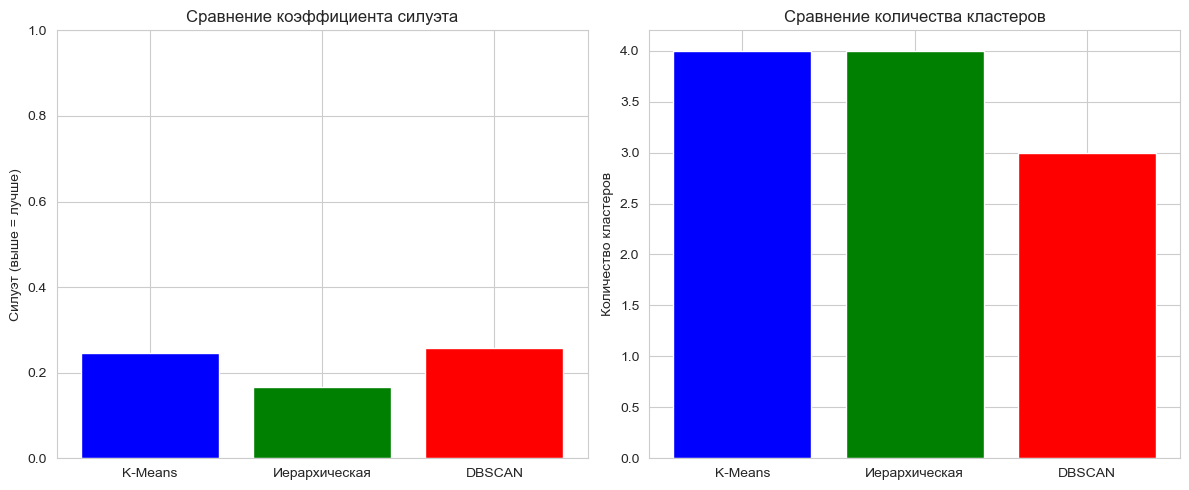

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(comparison['Метод'], comparison['Силуэт'], color=['blue', 'green', 'red'])
axes[0].set_title('Сравнение коэффициента силуэта')
axes[0].set_ylabel('Силуэт (выше = лучше)')
axes[0].set_ylim(0, 1)

axes[1].bar(comparison['Метод'], comparison['Кластеров'], color=['blue', 'green', 'red'])
axes[1].set_title('Сравнение количества кластеров')
axes[1].set_ylabel('Количество кластеров')

plt.tight_layout()
plt.show()

In [102]:
best_method = comparison.loc[comparison['Силуэт'].idxmax(), 'Метод']
print(f"\n Лучший метод: {best_method}")


 Лучший метод: DBSCAN


In [112]:
comparison_df = df[['Country']].copy()
comparison_df['K-Means'] = kmeans_labels
comparison_df['Agglomerative'] = agglo_labels
comparison_df['DBSCAN'] = dbscan_labels

comparison_df['Region'] = df['Region']

print("Сравнение кластеризации для первых 15 стран:")
comparison_df.head(15)

Сравнение кластеризации для первых 15 стран:


,Country,K-Means,Agglomerative,DBSCAN,Region
0,United States of America,3,3,-1,Americas
1,China,1,0,-1,Asia-Pacific
2,United Kingdom,1,0,-1,Europe
3,Canada,1,0,-1,Americas
4,Israel,1,0,-1,Middle East
5,Singapore,1,0,-1,Asia-Pacific
6,South Korea,1,0,-1,Asia-Pacific
7,The Netherlands,1,0,-1,Europe
8,Germany,1,0,-1,Europe
9,France,1,0,0,Europe


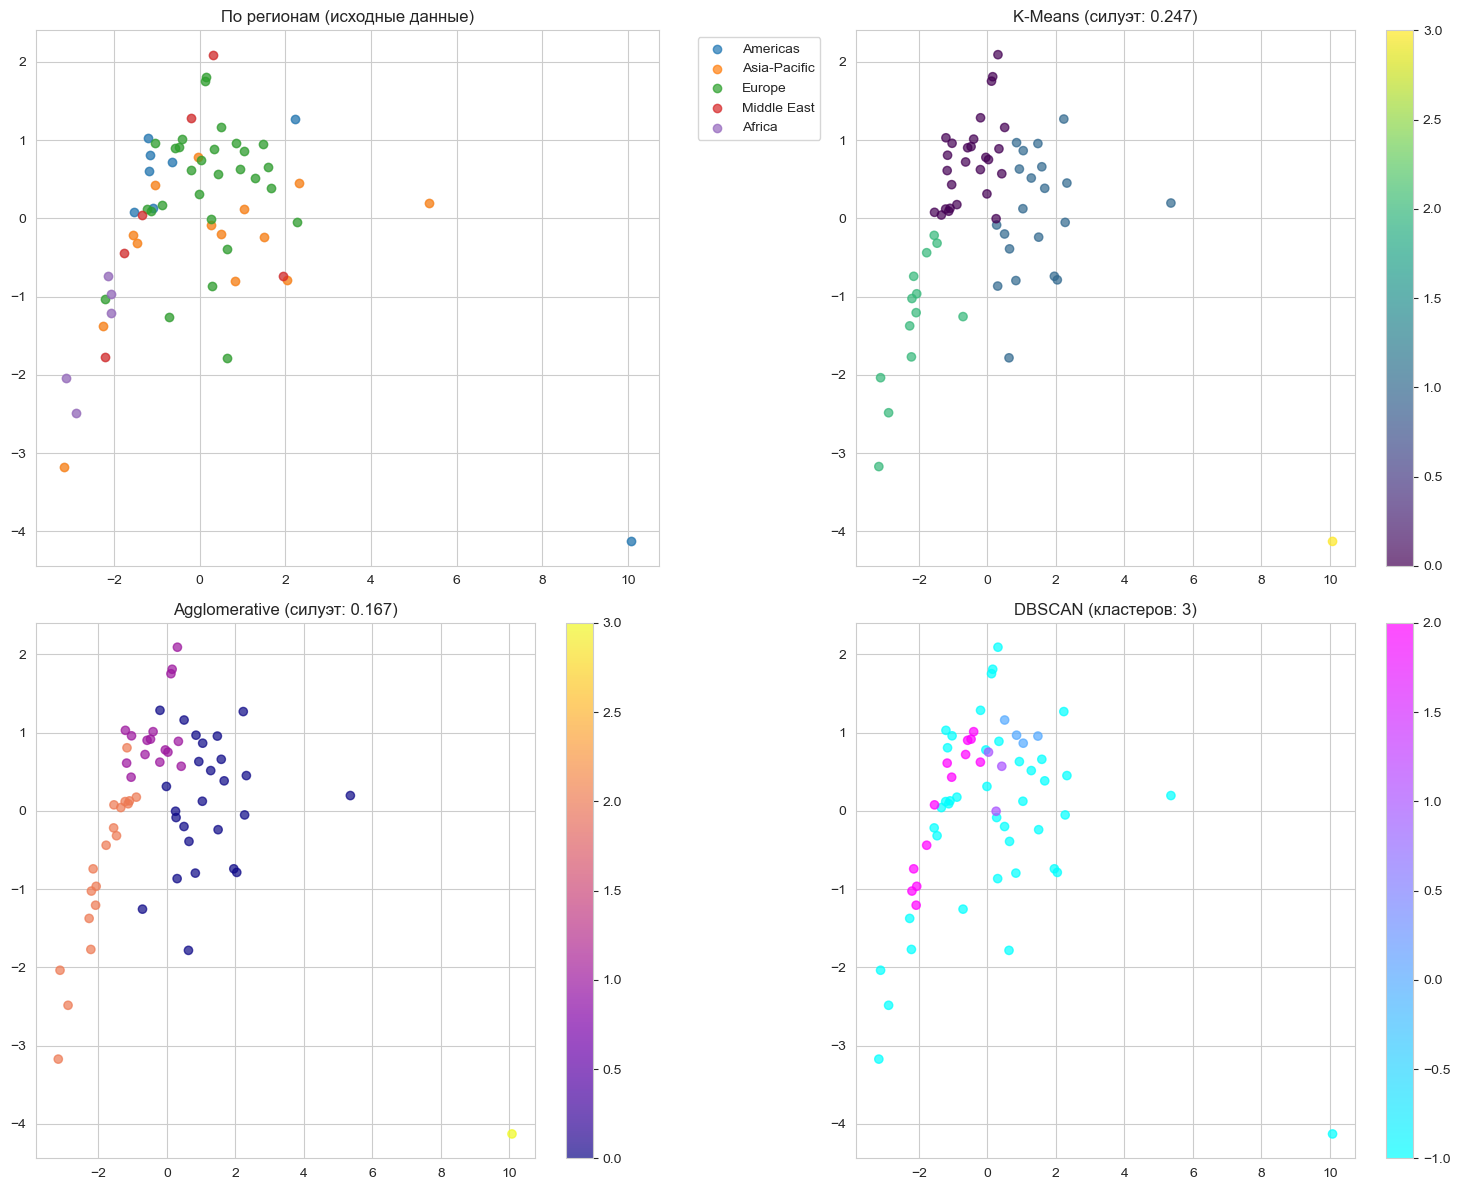

In [111]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

viz_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Country': df['Country'],
    'Region': df['Region'],
    'KMeans': kmeans_labels,
    'Agglo': agglo_labels,
    'DBSCAN': dbscan_labels
})

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].scatter(viz_df['PC1'], viz_df['PC2'], c='lightgray', alpha=0.6)
for region in viz_df['Region'].unique():
    mask = viz_df['Region'] == region
    axes[0, 0].scatter(viz_df.loc[mask, 'PC1'], viz_df.loc[mask, 'PC2'], 
                       label=region, alpha=0.7)
axes[0, 0].set_title('По регионам (исходные данные)')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# K-Means
scatter = axes[0, 1].scatter(viz_df['PC1'], viz_df['PC2'], 
                             c=viz_df['KMeans'], cmap='viridis', alpha=0.7)
axes[0, 1].set_title(f'K-Means (силуэт: {kmeans_silhouette:.3f})')
plt.colorbar(scatter, ax=axes[0, 1])

# Agglomerative
scatter = axes[1, 0].scatter(viz_df['PC1'], viz_df['PC2'], 
                             c=viz_df['Agglo'], cmap='plasma', alpha=0.7)
axes[1, 0].set_title(f'Agglomerative (силуэт: {agglo_silhouette:.3f})')
plt.colorbar(scatter, ax=axes[1, 0])

# DBSCAN
scatter = axes[1, 1].scatter(viz_df['PC1'], viz_df['PC2'], 
                             c=viz_df['DBSCAN'], cmap='cool', alpha=0.7)
axes[1, 1].set_title(f'DBSCAN (кластеров: {n_clusters_db})')
plt.colorbar(scatter, ax=axes[1, 1])

plt.tight_layout()
plt.show()

### МЕТОД ГЛАВНЫХ КОМПОНЕНТ (PCA - ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ) 

PC1 сохраняет: 58.1% информации
PC2 сохраняет: 19.1% информации
ВСЕГО сохранили: 77.3% информации

ВАЖНОСТЬ ПРИЗНАКОВ В КОМПОНЕНТАХ:
     Talent  Infrastructure  Operating Environment  Research  Development  \
PC1   0.422           0.356                  0.174     0.466        0.436   
PC2  -0.226           0.363                  0.639    -0.167       -0.162   

     Government Strategy  Commercial  
PC1                0.284       0.421  
PC2                0.497      -0.328  


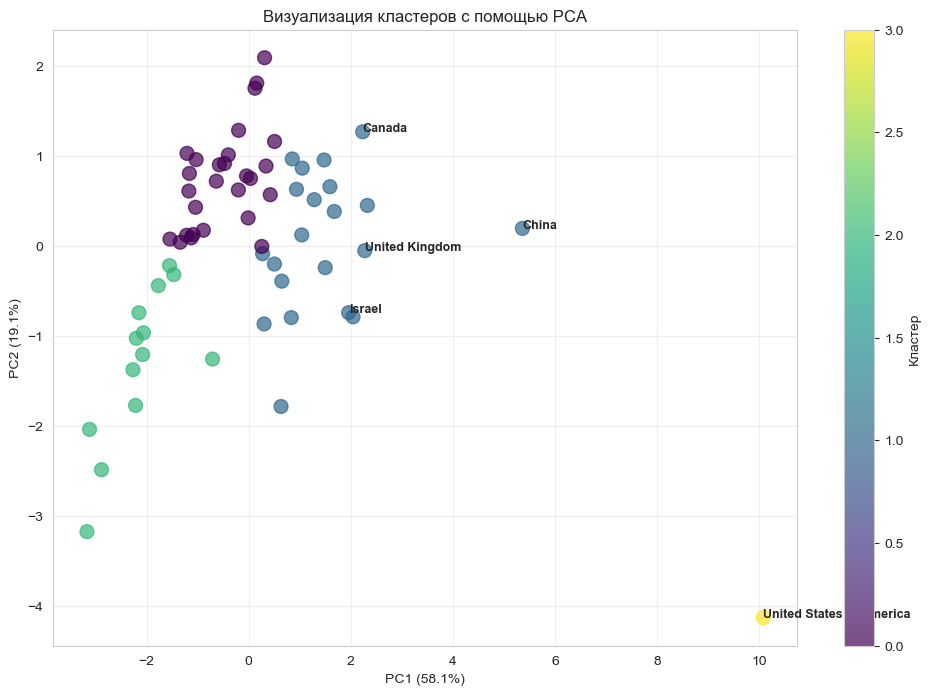

In [110]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print(f"PC1 сохраняет: {explained_variance[0]:.1%} информации")
print(f"PC2 сохраняет: {explained_variance[1]:.1%} информации")
print(f"ВСЕГО сохранили: {sum(explained_variance):.1%} информации")

components = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PC1', 'PC2']
)
print("\nВАЖНОСТЬ ПРИЗНАКОВ В КОМПОНЕНТАХ:")
print(components.round(3))


final_labels = kmeans_labels  

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=final_labels, cmap='viridis', 
                     s=100, alpha=0.7)

top_countries = df.nlargest(5, 'Total score')['Country'].tolist()
for i, country in enumerate(df['Country']):
    if country in top_countries:
        plt.annotate(country, (X_pca[i, 0], X_pca[i, 1]), 
                    fontsize=9, fontweight='bold')

plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({explained_variance[0]:.1%})')
plt.ylabel(f'PC2 ({explained_variance[1]:.1%})')
plt.title('Визуализация кластеров с помощью PCA')
plt.grid(True, alpha=0.3)
plt.show()

Мы видим результаты метода главных компонент (PCA) для визуализации кластеров стран. 
PC1 объясняет 58.1% информации - это очень хороший показатель
PC2 объясняет 19.1% информации

Вместе: 77.3% всей информации сохранено в двух компонентах, мы успешно сократили размерность данных с 7 признаков до 2 главных компонент, потеряв всего 22.7% информации.

PC1 (главная компонента):имеет высокие положительные нагрузки по всем признакам: Talent (0.422), Research (0.466), Development (0.436), Infrastructure (0.356)
Это "общий уровень развития" - интегральный показатель инновационного потенциала
PC2 (вторая компонента):сильно нагружена Operating Environment (0.639) и Government Strategy (0.497)
Это "институциональная среда и государственная поддержка"

На графике видно четкое разделение стран на кластеры:
США - явный лидер (правый нижний угол, PC1 ≈ 10)
Китай, Великобритания, Канада, Израиль - страны с высоким потенциалом
Остальные страны образуют отдельные группы
